<a target="_blank" href="https://colab.research.google.com/github/CosmoStatGW/gwfast/blob/master/notebooks/gwfast_tutorial.ipynb"> <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
import lalsimulation as lalsim

import h5py

from tqdm import tqdm
from scipy.io.wavfile import write

import matplotlib.pyplot as plt
from matplotlib import rc
rc('text', usetex=True)

### Settings

In [2]:
FMIN = 10. # Hz
DELTA_T = 1./4096. # seconds
SEGLEN = 10 # minutes

tsamples = int(SEGLEN*60 / DELTA_T) # number of samples in the time series

### Utility functions

In [3]:
def m1m2_from_Mceta(Mc, eta):
    """
    Compute the component masses of a binary given its chirp mass and symmetric mass ratio.
    
    :param array or float Mc: Chirp mass of the binary, :math:`{\cal M}_c`.
    :param array or float eta: The symmetric mass ratio(s), :math:`\eta`, of the objects.
    :return: :math:`m_1` and :math:`m_2`.
    :rtype: tuple(array, array) or tuple(float, float)
    
    """
    Seta = np.sqrt(1.0 - 4.0*eta)
    m1 = 0.5*(Mc/(eta**(3./5.)))*(1. + Seta)
    m2 = 0.5*(Mc/(eta**(3./5.)))*(1. - Seta)

    return m1, m2

In [4]:
def get_h_td(evParams, waveform_approximant=lalsim.IMRPhenomT, tsamples=4096*4):
    """
    Compute the time domain waveform for a given set of event parameters, using lalsim. The waveform is computed at a random time shift and then padded with zeros to get the desired length of the time series.

    :param dict(array, array, ...) evParams: Dictionary containing the parameters of the events. The keys must be: 'Mc', 'eta', 'chi1z', 'chi2z', 'dL', 'iota', 'Phicoal'.
    :param lalsim waveform_approximant: Waveform approximant to use from lalsim, defaults to lalsim.IMRPhenomT
    :param int tsamples: Number of samples in the time series, defaults to 4096*4
    
    :return : Time domain time series of the chosen length with the waveform h(t) for the given event parameters at a random time shift.
    :rtype : array
    """
    
    m1, m2 = m1m2_from_Mceta(evParams['Mc'], evParams['eta'])
    try:
        hp, hc = lalsim.SimInspiralChooseTDWaveform(
                    m1=m1*lal.MSUN_SI,
                    m2=m2*lal.MSUN_SI,
                    s1x= 0,
                    s1y= 0,
                    s1z=evParams['chi1z'],
                    s2x= 0,
                    s2y= 0,
                    s2z=evParams['chi2z'],
                    distance=evParams['dL']*1e9*lal.PC_SI,
                    inclination=evParams['iota'],
                    phiRef=evParams['Phicoal'],
                    longAscNodes=0,
                    eccentricity=0,
                    meanPerAno=0,
                    deltaT=DELTA_T,
                    f_min=FMIN,
                    f_ref=FMIN,
                    params=lal.CreateDict(),
                    approximant=waveform_approximant,
                    )
    except Exception as e:
        print('Error in SimInspiralChooseTDWaveform:', e)
        return np.zeros(tsamples).astype(float)
        
    hp, hc = np.array(hp.data.data), np.array(hc.data.data)
    
    timeshift = np.random.randint(0, tsamples)
    
    # Padding with zeros to get the desired length of the time series
    if tsamples - len(hp)-timeshift > 0:
        enlargedsignal = np.concatenate([np.zeros(timeshift), hp - hc, np.zeros(tsamples - len(hp)-timeshift)])
    elif len(hp) > tsamples:
        enlargedsignal = np.concatenate([(hp - hc)[tsamples:]])
    else:
        enlargedsignal = np.concatenate([np.zeros(timeshift), (hp - hc)[:tsamples - len(hp)-timeshift]])

    return enlargedsignal

In [5]:
def load_population(name, nEventsUse=None):
    
    """
    Load a dictionary containing the events parameters in h5 file.
    
    :param str name: The name of the file to load the events from. This has to include the path and the ``h5`` or ``hdf5`` extension.
    :param int or None nEventsUse: Number of the events in the given file to load. If None, all the events in the file are loaded. Defaults to None.
    
    :return: Dictionary containing the loaded events.
    :rtype: dict(array, array, ...)
    
    """
    
    events={}
    with h5py.File(name, 'r') as f:
        for key in f.keys():
            events[key] = f[key][:nEventsUse] if nEventsUse is not None else f[key][:]
    keys_needed = ['Mc', 'eta', 'chi1z', 'chi2z', 'dL', 'iota', 'Phicoal']
    
    if 'm1' in events and 'm2' in events and ('Mc' not in events or 'eta' not in events):
        m1, m2 = events['m1'], events['m2']
        Mc = (m1*m2)**(3./5.)/(m1+m2)**(1./5.)
        eta = (m1*m2)/(m1+m2)**2
        events['Mc'] = Mc
        events['eta'] = eta
    
    for key in keys_needed:
        if key not in events:
            raise ValueError(f"Key '{key}' not found in the loaded events. The file must contain the following keys: {keys_needed}")
    return events

### Computation

In [6]:
# Load the events, only 100 to test, there are 10^4 total in the files
BBHCat = load_population('BBHCat_small.h5', nEventsUse=1000)

np.random.seed(42) # for reproducibility

In [ ]:
# Compute the time domain waveforms for all the events and average them to get the final output strain for the BBH population.
Nevs_tot = len(BBHCat['dL'])
outstrain_BBH = np.zeros(tsamples).astype(float) 
for iev in tqdm(range(Nevs_tot), desc='Computing waveforms and averaging', unit='events'):
    tmpev = {k:BBHCat[k][iev] for k in BBHCat.keys()}
    outstrain_BBH += get_h_td(tmpev, waveform_approximant=lalsim.IMRPhenomTHM, tsamples=tsamples)
outstrain_BBH /= Nevs_tot
time_grid = np.arange(tsamples)*DELTA_T

Computing waveforms and averaging: 100%|██████████| 1000/1000 [00:29<00:00, 33.72event/s]


### Plot

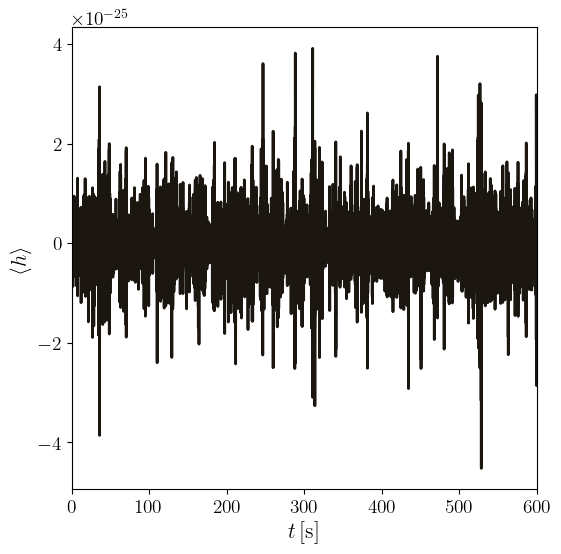

In [8]:
rasterization_use = 100 # Do not plot all the samples to have a lighter plot

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(time_grid[::rasterization_use], outstrain_BBH[::rasterization_use], label=r'\textrm{BBHs}', color='#1B1610', lw=2)
ax.tick_params(axis='both', which='major', colors='black', labelsize=14)
ax.yaxis.get_offset_text().set_fontsize(14)
plt.ylabel(r'$\langle h \rangle$', fontsize=16)
plt.xlabel(r'$t\,[{\rm s}]$', fontsize=16)
plt.xlim(0, 600)
plt.show()

### Produce output audio

In [9]:
time_signal = outstrain_BBH / np.max(np.abs(outstrain_BBH))
write("output_audio_universal_bbhsmall.wav", int(1/DELTA_T), (time_signal * 32767).astype(np.int16))